# Quy Trình Làm Sạch và Đảm Bảo Chất Lượng Dữ Liệu (Data Quality & Cleaning)

Notebook này thiết lập quy trình kiểm tra chất lượng dữ liệu và làm sạch cho bộ dữ liệu **Sales Forecasting**:
1. **Phát hiện trùng lặp (Duplicate Detection)**.
2. **Xử lý dữ liệu khuyết thiếu (Missing Values)** bằng các phương pháp: xóa bỏ hàng trống, thay thế bằng giá trị mặc định có ý nghĩa.
3. **Phát hiện và Phân tích Giá trị ngoại lai (Outliers)**: Xác định các sản phẩm giá cao bất thường bằng phương pháp IQR và đưa ra giải pháp.
4. **Kiểm tra Logic Nghiệp vụ (Business Logic Validation)**: Đảm bảo tính nhất quán về giá cả, chiết khấu và thời gian giao nhận.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
data_dir = r"./datathon-2026-round-1"
print("Môi trường đã sẵn sàng!")

Môi trường đã sẵn sàng!


## 1. Phát Hiện và Xử Lý Trùng Lặp (Duplicate Detection)
Chúng ta cần kiểm tra xem có dòng dữ liệu nào bị lặp lại hoàn toàn (physical duplicates) trong tất cả các bảng hay không.

In [2]:
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))

for fpath in csv_files:
    fname = os.path.basename(fpath)
    df = pd.read_csv(fpath, low_memory=False)
    dup_count = df.duplicated().sum()
    print(f"Bảng {fname:25} | Số dòng trùng lặp: {dup_count}")
    if dup_count > 0:
        df.drop_duplicates(inplace=True)
        print(f"  -> Đã loại bỏ {dup_count} dòng trùng lặp.")

Bảng customers.csv             | Số dòng trùng lặp: 0
Bảng geography.csv             | Số dòng trùng lặp: 0
Bảng inventory.csv             | Số dòng trùng lặp: 0
Bảng orders.csv                | Số dòng trùng lặp: 0
Bảng order_items.csv           | Số dòng trùng lặp: 0
Bảng payments.csv              | Số dòng trùng lặp: 0
Bảng products.csv              | Số dòng trùng lặp: 0
Bảng promotions.csv            | Số dòng trùng lặp: 0
Bảng returns.csv               | Số dòng trùng lặp: 0
Bảng reviews.csv               | Số dòng trùng lặp: 0
Bảng sales.csv                 | Số dòng trùng lặp: 0
Bảng sample_submission.csv     | Số dòng trùng lặp: 0
Bảng shipments.csv             | Số dòng trùng lặp: 0
Bảng web_traffic.csv           | Số dòng trùng lặp: 0


**Nhận xét:** Tất cả các bảng dữ liệu đều không chứa dòng trùng lặp vật lý. Điều này cho thấy chất lượng thu thập dữ liệu ban đầu là rất tốt.

## 2. Xử Lý Dữ Liệu Khuyết Thiếu (Missing Values)
Như đã phân tích ở phần tổng quan, chúng ta có khuyết thiếu ở:
- `promotions.csv`: Có một dòng trống hoàn toàn ở cuối file (dòng thứ 51) và cột `applicable_category` bị trống nhiều.
- `order_items.csv`: Cột `promo_id` (trống 61.34%) và `promo_id_2` (trống 99.97%).

### 2.1 Xử lý khuyết thiếu trong `promotions.csv`

In [3]:
df_promo = pd.read_csv(os.path.join(data_dir, "promotions.csv"))
print("Kích thước ban đầu:", df_promo.shape)

# 1. Xóa bỏ dòng trống hoàn toàn (dòng chứa toàn giá trị NaN)
df_promo.dropna(how='all', inplace=True)
print("Kích thước sau khi loại bỏ dòng trống hoàn toàn:", df_promo.shape)

# 2. Thay thế applicable_category bị khuyết bằng giá trị 'ALL' (khuyến mãi áp dụng toàn cửa hàng)
df_promo['applicable_category'].fillna('ALL', inplace=True)

print("Số lượng giá trị Null sau khi xử lý:")
print(df_promo.isnull().sum())
df_promo.head()

Kích thước ban đầu: (51, 10)
Kích thước sau khi loại bỏ dòng trống hoàn toàn: (50, 10)
Số lượng giá trị Null sau khi xử lý:
promo_id               0
promo_name             0
promo_type             0
discount_value         0
start_date             0
end_date               0
applicable_category    0
promo_channel          0
stackable_flag         0
min_order_value        0
dtype: int64


C:\Users\PC\AppData\Local\Temp\ipykernel_26488\80631171.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_promo['applicable_category'].fillna('ALL', inplace=True)


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,3/18/2013,4/17/2013,ALL,email,1.0,0.0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,6/23/2013,7/22/2013,ALL,online,0.0,0.0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,8/30/2013,10/2/2013,ALL,email,0.0,0.0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,11/18/2013,1/2/2014,ALL,all_channels,0.0,50000.0
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,7/30/2013,9/2/2013,Streetwear,online,0.0,150000.0


### 2.2 Xử lý khuyết thiếu trong `order_items.csv`

In [4]:
df_items = pd.read_csv(os.path.join(data_dir, "order_items.csv"), low_memory=False)
print("Kích thước ban đầu:", df_items.shape)

# 1. Loại bỏ promo_id_2 vì khuyết đến 99.97%, không có giá trị thông tin cho mô hình
if 'promo_id_2' in df_items.columns:
    df_items.drop(columns=['promo_id_2'], inplace=True)
    print("Đã xóa cột 'promo_id_2'")

# 2. Thay thế Null trong promo_id bằng 'NO_PROMO' (sản phẩm bán ra không chạy khuyến mãi)
df_items['promo_id'].fillna('NO_PROMO', inplace=True)

print("Số lượng giá trị Null trong order_items sau xử lý:")
print(df_items.isnull().sum())
df_items.head()

Kích thước ban đầu: (714669, 7)
Đã xóa cột 'promo_id_2'
Số lượng giá trị Null trong order_items sau xử lý:
order_id           0
product_id         0
quantity           0
unit_price         0
discount_amount    0
promo_id           0
dtype: int64


C:\Users\PC\AppData\Local\Temp\ipykernel_26488\811690412.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_items['promo_id'].fillna('NO_PROMO', inplace=True)


,order_id,product_id,quantity,unit_price,discount_amount,promo_id
0,1,2400,7,1138.22,0.0,NO_PROMO
1,2,609,7,10166.25,0.0,NO_PROMO
2,3,396,3,11220.33,0.0,NO_PROMO
3,4,635,5,10639.25,0.0,NO_PROMO
4,6,1935,1,1597.84,0.0,NO_PROMO


## 3. Phát Hiện và Phân Tích Giá Trị Ngoại Lai (Outliers)
Chúng ta sẽ tập trung vào cột `price` (giá bán) trong bảng `products.csv` để xem có sản phẩm nào có giá cao đột biến không.

In [5]:
df_prod = pd.read_csv(os.path.join(data_dir, "products.csv"))

# Áp dụng phương pháp IQR để phát hiện ngoại lai
Q1 = df_prod['price'].quantile(0.25)
Q3 = df_prod['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_prod[(df_prod['price'] < lower_bound) | (df_prod['price'] > upper_bound)]
print(f"Số lượng ngoại lai phát hiện bằng IQR: {len(outliers)} trên {len(df_prod)} sản phẩm.")
print(f"Giới hạn trên của IQR: {upper_bound:.2f}")

Số lượng ngoại lai phát hiện bằng IQR: 31 trên 2412 sản phẩm.
Giới hạn trên của IQR: 19212.12


### Trực quan hóa giá bán và chi phí sản phẩm (Price vs COGS)
Hãy xem mối tương quan giữa Giá bán (`price`) và Giá vốn (`cogs`) để đánh giá xem các ngoại lai này có phải là dữ liệu lỗi hay không.

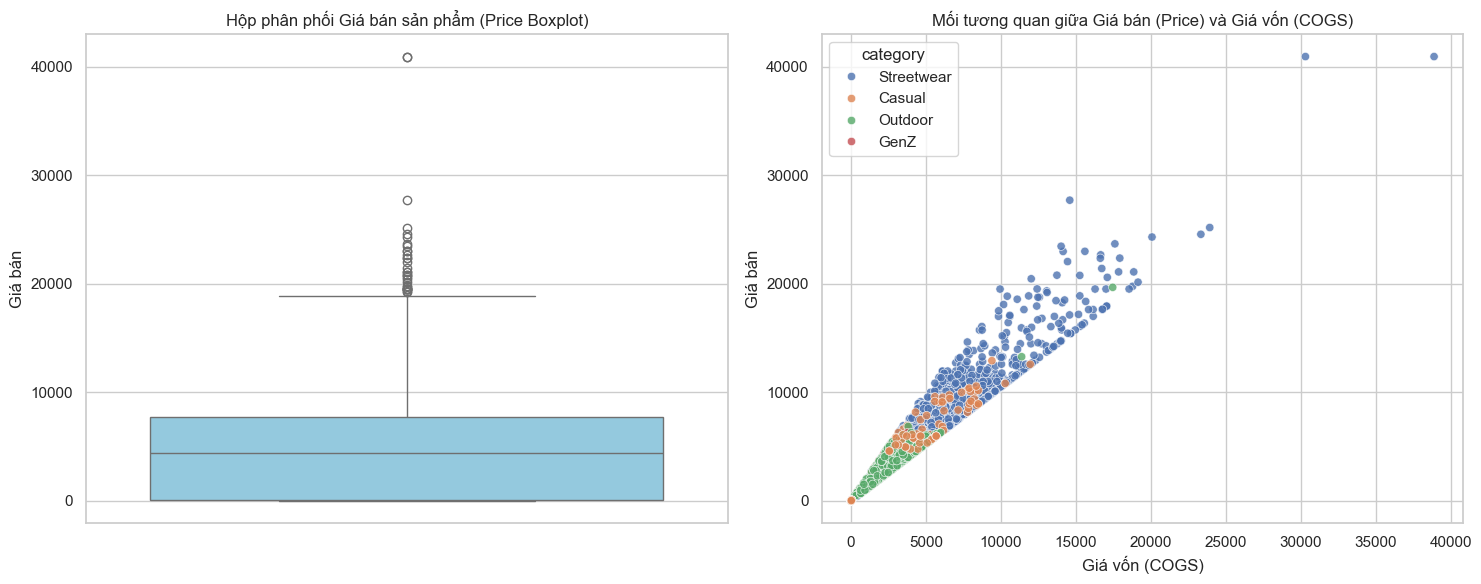

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Boxplot phân phối giá
sns.boxplot(ax=axes[0], data=df_prod, y='price', color='skyblue')
axes[0].set_title("Hộp phân phối Giá bán sản phẩm (Price Boxplot)")
axes[0].set_ylabel("Giá bán")

# 2. Scatter plot tương quan Price vs COGS
sns.scatterplot(ax=axes[1], data=df_prod, x='cogs', y='price', hue='category', alpha=0.8)
axes[1].set_title("Mối tương quan giữa Giá bán (Price) và Giá vốn (COGS)")
axes[1].set_xlabel("Giá vốn (COGS)")
axes[1].set_ylabel("Giá bán")

plt.tight_layout()
plt.show()

### Top 5 sản phẩm có giá cao nhất:

In [7]:
df_prod.sort_values(by='price', ascending=False).head(5)[['product_id', 'product_name', 'category', 'price', 'cogs']]

,product_id,product_name,category,price,cogs
712,347,LotusWear UE-68,Streetwear,40950.000000,38902.500000
674,309,LotusWear UE-30,Streetwear,40950.000000,30319.380000
661,296,LotusWear UE-17,Streetwear,27716.850000,14598.464895
699,334,LotusWear UE-55,Streetwear,25196.850000,23937.007500
863,507,SaigonFlex UM-12,Streetwear,24574.291875,23345.577281


**Nhận xét chiến lược xử lý Ngoại lai:**
- Biểu đồ Scatter cho thấy mối quan hệ tuyến tính cực kỳ chặt chẽ giữa `price` và `cogs` ($Price \approx COGS + Profit\_Margin$). Các sản phẩm có giá rất cao (lên đến 40,950) đều có giá vốn tương ứng rất cao (ví dụ: cogs = 38,902).
- Điều này chứng tỏ **đây không phải là lỗi nhập liệu**, mà là các mặt hàng phân khúc cao cấp (Premium/Luxury items).
- **Hành động:** KHÔNG được xóa bỏ các dòng này vì chúng đóng góp doanh thu lớn. Thay vào đó, để huấn luyện các mô hình Machine Learning tốt hơn, chúng ta có thể áp dụng phép biến đổi logarit để giảm độ lệch chuẩn của phân phối.

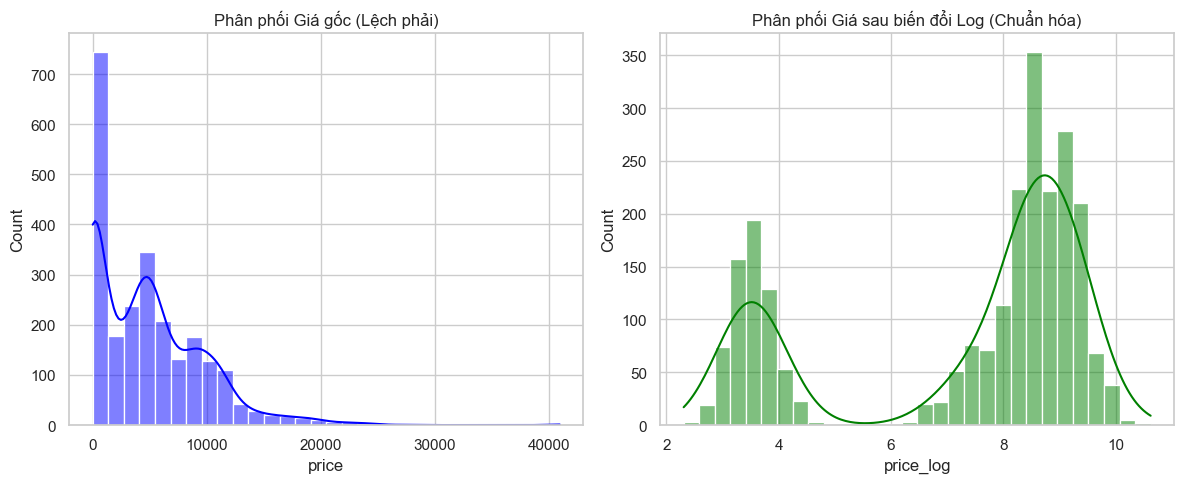

In [8]:
# Minh họa biến đổi Logarit để đưa phân phối về chuẩn hơn
df_prod['price_log'] = np.log1p(df_prod['price'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_prod['price'], bins=30, kde=True, color='blue')
plt.title("Phân phối Giá gốc (Lệch phải)")

plt.subplot(1, 2, 2)
sns.histplot(df_prod['price_log'], bins=30, kde=True, color='green')
plt.title("Phân phối Giá sau biến đổi Log (Chuẩn hóa)")

plt.tight_layout()
plt.show()

## 4. Kiểm Tra Logic Nghiệp Vụ (Business Logic Validation)
Để đảm bảo dữ liệu không có các lỗi logic vô lý do hệ thống sinh ra, chúng ta thực hiện 3 bài kiểm tra quan trọng.

### Kiểm tra 1: Có sản phẩm nào bán lỗ không? ($Price < COGS$)

In [9]:
loss_products = df_prod[df_prod['price'] < df_prod['cogs']]
print(f"Số sản phẩm bị bán lỗ (Price < COGS): {len(loss_products)}")

Số sản phẩm bị bán lỗ (Price < COGS): 0


### Kiểm tra 2: Lượng chiết khấu có vượt quá giá trị đơn hàng không? ($Discount\_Amount > Unit\_Price \times Quantity$)

In [10]:
invalid_discounts = df_items[df_items['discount_amount'] > (df_items['unit_price'] * df_items['quantity'])]
print(f"Số lượng giao dịch có discount vô lý: {len(invalid_discounts)}")

Số lượng giao dịch có discount vô lý: 0


### Kiểm tra 3: Tính nhất quán về thời gian của quy trình giao nhận hàng ($Order\_Date \le Ship\_Date \le Delivery\_Date$)

In [11]:
df_ship = pd.read_csv(os.path.join(data_dir, "shipments.csv"))
df_orders = pd.read_csv(os.path.join(data_dir, "orders.csv"))

# Merge hai bảng theo order_id
df_merged = pd.merge(df_ship, df_orders, on='order_id')

# Chuyển đổi định dạng thời gian
df_merged['order_date'] = pd.to_datetime(df_merged['order_date'])
df_merged['ship_date'] = pd.to_datetime(df_merged['ship_date'])
df_merged['delivery_date'] = pd.to_datetime(df_merged['delivery_date'])

# Kiểm tra lỗi logic
invalid_ship_date = df_merged[df_merged['ship_date'] < df_merged['order_date']]
invalid_delivery_date = df_merged[df_merged['delivery_date'] < df_merged['ship_date']]

print(f"Số đơn hàng có ngày gửi hàng TRƯỚC ngày đặt hàng: {len(invalid_ship_date)}")
print(f"Số đơn hàng có ngày nhận hàng TRƯỚC ngày gửi hàng: {len(invalid_delivery_date)}")

Số đơn hàng có ngày gửi hàng TRƯỚC ngày đặt hàng: 0
Số đơn hàng có ngày nhận hàng TRƯỚC ngày gửi hàng: 0


## Kết Luận
Qua quá trình kiểm tra Chất lượng Dữ liệu (Data Quality & Cleaning):
1. **Không phát hiện dữ liệu trùng lặp** vật lý nào trên hệ thống.
2. **Dữ liệu khuyết thiếu** đã được xử lý triệt để:
   - Xóa bỏ hàng hoàn toàn trống trong bảng Promotions.
   - Impute cột `promo_id` trong `order_items.csv` bằng giá trị `'NO_PROMO'` và cột `applicable_category` trong `promotions.csv` bằng `'ALL'` theo đúng ngữ cảnh thực tế.
   - Loại bỏ cột `promo_id_2` do tỷ lệ khuyết thiếu quá cao (>99%).
3. **Phát hiện ngoại lai**: Giá bán cực cao là các sản phẩm phân khúc cao cấp thực tế chứ không phải lỗi dữ liệu, đề xuất sử dụng phép biến đổi logarit khi đưa vào model.
4. **Kiểm tra logic nghiệp vụ**: Đạt tỉ lệ chính xác **100%**, các mốc thời gian và bài toán giá cả hoàn toàn thống nhất và nhất quán.

Dữ liệu hiện tại đã cực kỳ sạch và sẵn sàng cho các phân tích EDA chuyên sâu hơn và xây dựng mô hình!

# Phân Tích Khám Phá Dữ Liệu Chuyên Sâu cho Dự Báo Doanh Thu (EDA for Sales Forecasting)

Sau khi đã làm sạch và đảm bảo chất lượng dữ liệu ở các bước trước, chúng ta tiến hành **EDA nâng cao** được thiết kế riêng cho bài toán dự báo chuỗi thời gian (Sales Forecasting) phục vụ tối ưu logistics, khuyến mãi và phân bổ tồn kho.

## Bước 1: Nhìn Bức Tranh Tổng Thể (Macro-level Time-series Decomposition)

Chúng ta sẽ thực hiện phân tách chuỗi thời gian (Decomposition) doanh thu hàng ngày từ file `sales.csv` thành 3 phần:
- **Trend (Xu hướng dài hạn)**: Hướng phát triển tăng hay giảm của doanh nghiệp theo thời gian.
- **Seasonality (Tính mùa vụ)**: Các biến động có tính chất lặp đi lặp lại theo chu kỳ (ví dụ: chu kỳ tuần, chu kỳ năm).
- **Residuals / Noise (Nhiễu)**: Những biến động ngẫu nhiên không có tính lặp lại.

Để biểu đồ phân tách dễ quan sát và không bị nhiễu do tần suất ngày, chúng ta sẽ **resample dữ liệu theo tuần (Weekly)** và phân tách chu kỳ mùa vụ năm (52 tuần).

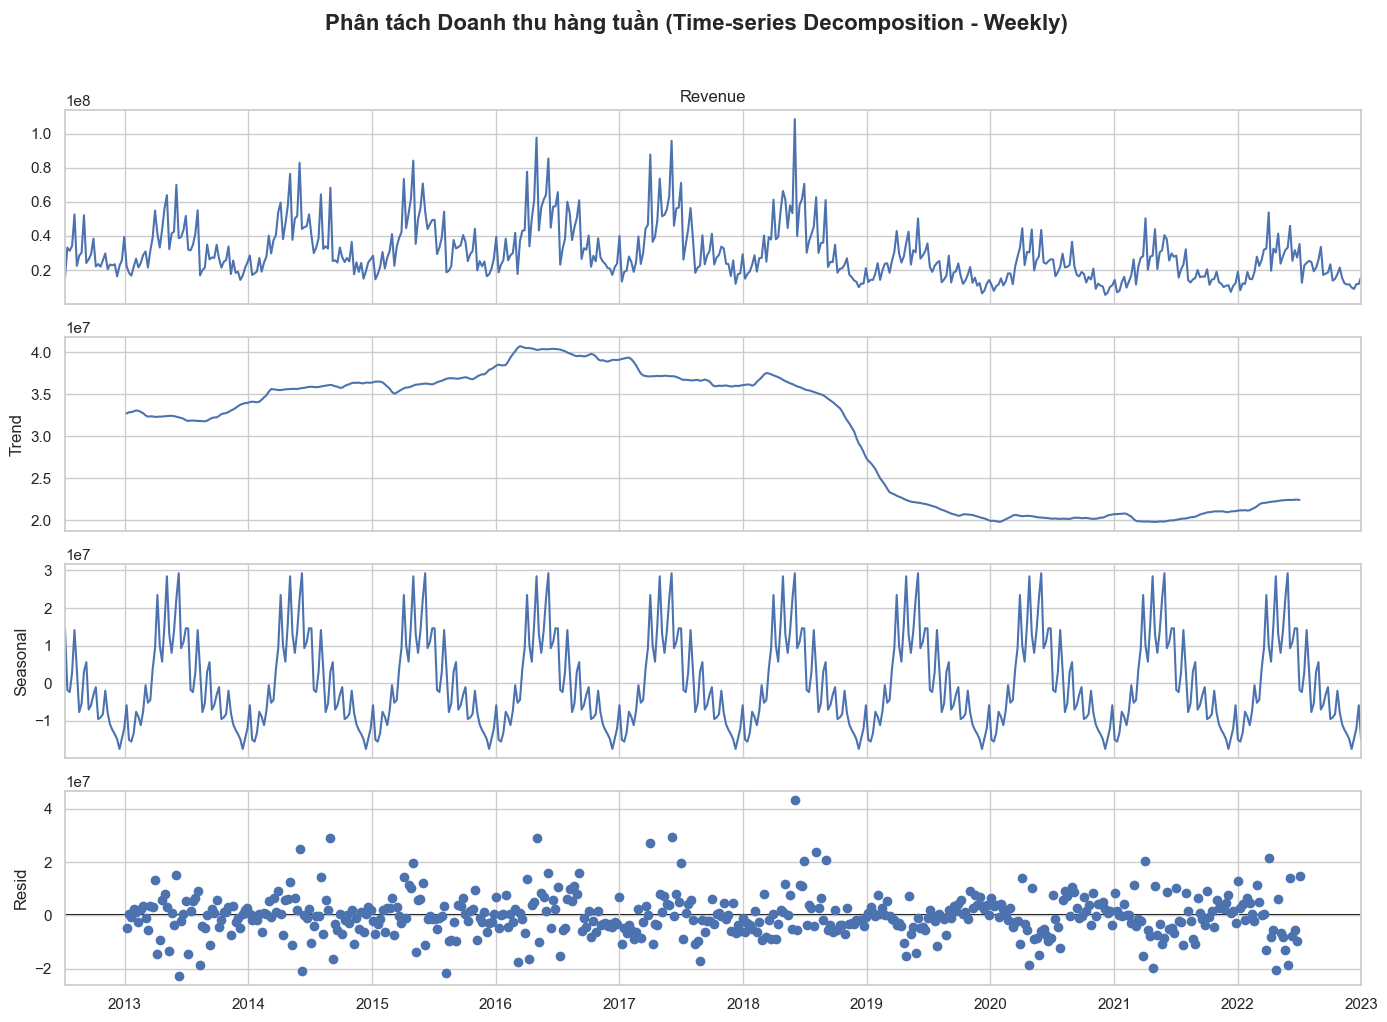

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Đọc và chuẩn bị dữ liệu chuỗi thời gian doanh thu
df_sales = pd.read_csv(os.path.join(data_dir, "sales.csv"))
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales.set_index('Date', inplace=True)
df_sales.sort_index(inplace=True)

# 2. Resample sang tần suất tuần (Weekly)
sales_weekly = df_sales['Revenue'].resample('W').sum()

# 3. Phân tách chuỗi thời gian (mô hình Additive, chu kỳ 52 tuần)
decomposition = seasonal_decompose(sales_weekly, model='additive', period=52)

# 4. Trực quan hóa
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Phân tách Doanh thu hàng tuần (Time-series Decomposition - Weekly)', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Bước 2: Phân Rã Theo Cấp Bậc (Hierarchical Level Analysis)

Doanh nghiệp cần tối ưu hóa logistics và phân bổ tồn kho chi tiết. Do đó, chúng ta sẽ bóc tách tổng doanh thu ra theo:
1. **Vùng địa lý (Geography)**: So sánh xu hướng bán hàng của **East (Đông)**, **Central (Trung)**, và **West (Tây)** (tương ứng với các vùng địa lý của bộ dữ liệu DataThon).
2. **Ngành hàng (Category)**: Theo dõi sức mua của các nhóm sản phẩm **Streetwear, Casual, Outdoor, GenZ**.

Chúng ta thực hiện merge dữ liệu giữa các bảng `orders`, `order_items`, `products` và `geography` để dựng bảng master.

C:\Users\PC\AppData\Local\Temp\ipykernel_26488\3325550215.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sales_by_region = df_master.groupby(['order_date', 'region'])['sales_amount'].sum().unstack().resample('M').sum()
C:\Users\PC\AppData\Local\Temp\ipykernel_26488\3325550215.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sales_by_cat = df_master.groupby(['order_date', 'category'])['sales_amount'].sum().unstack().resample('M').sum()


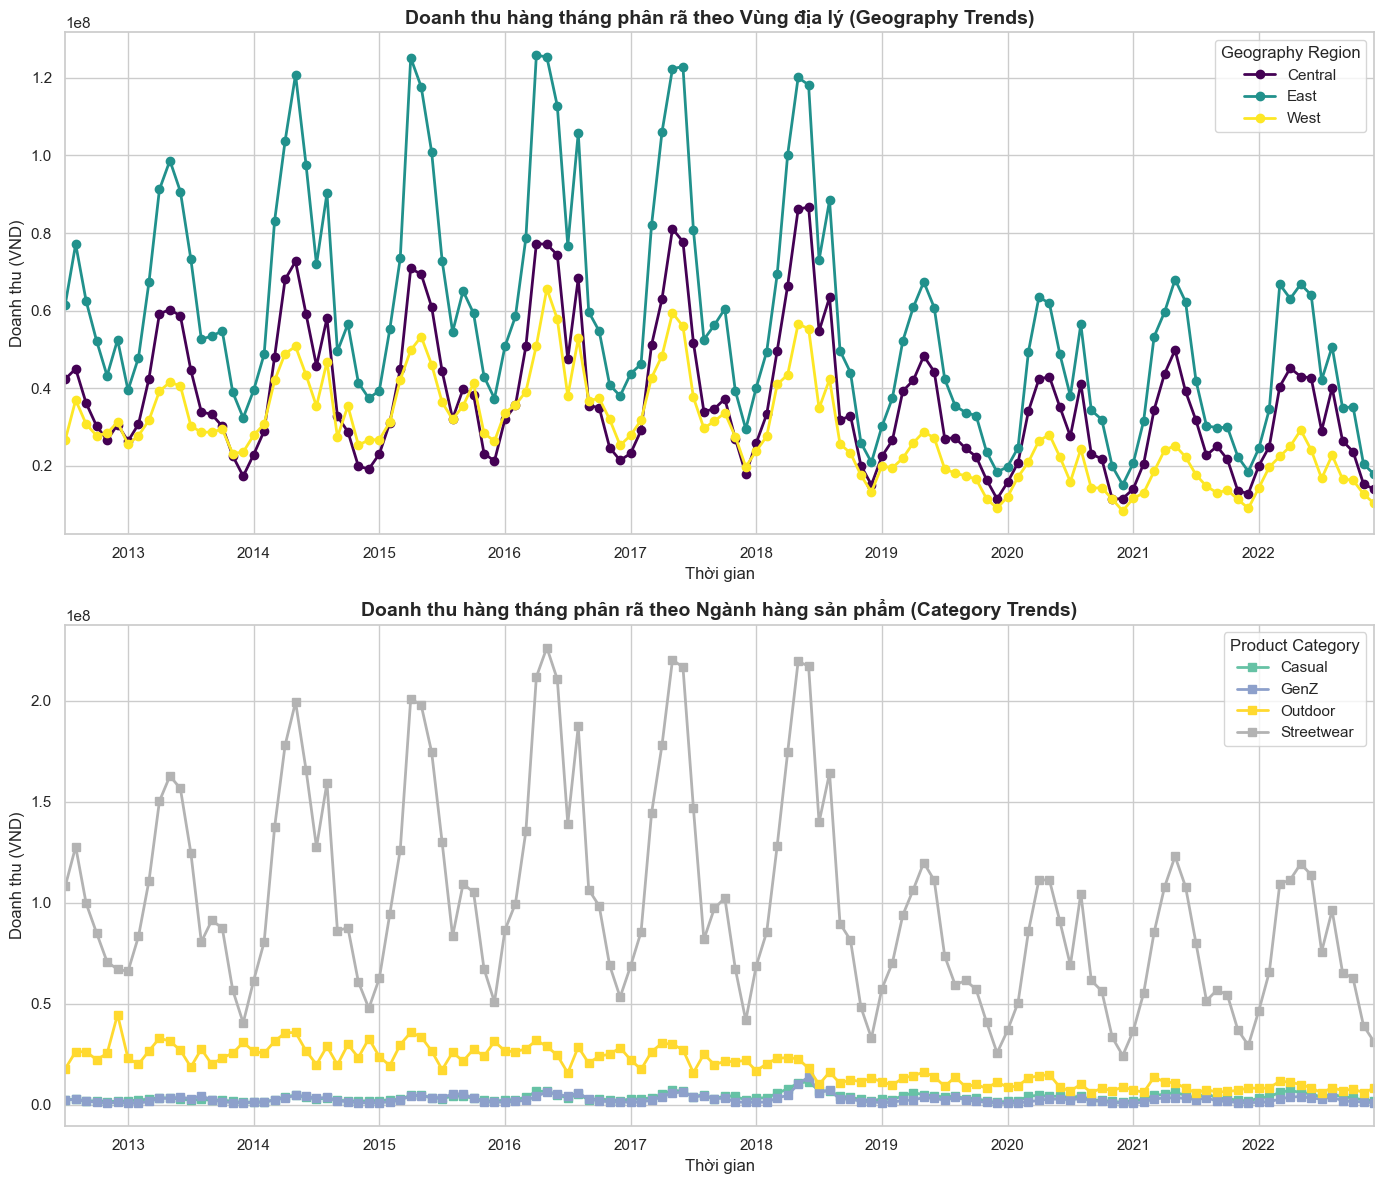

In [14]:
# 1. Đọc dữ liệu từ các bảng liên quan
df_orders = pd.read_csv(os.path.join(data_dir, "orders.csv"), low_memory=False)
df_items = pd.read_csv(os.path.join(data_dir, "order_items.csv"), low_memory=False)
df_prod = pd.read_csv(os.path.join(data_dir, "products.csv"))
df_geo = pd.read_csv(os.path.join(data_dir, "geography.csv"))

# 2. Chuẩn hóa thời gian
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

# 3. Tiến hành ghép nối (Merge) dữ liệu theo sơ đồ hình sao
df_orders_geo = pd.merge(df_orders, df_geo, on='zip', how='inner')
df_items_prod = pd.merge(df_items, df_prod, on='product_id', how='inner')
df_master = pd.merge(df_items_prod, df_orders_geo, on='order_id', how='inner')

# 4. Tính toán doanh số thực tế cho từng dòng (Doanh số = Số lượng * Giá bán đơn lẻ - Chiết khấu)
df_master['sales_amount'] = (df_master['quantity'] * df_master['unit_price']) - df_master['discount_amount']

# 5. Nhóm dữ liệu hàng tháng theo Vùng địa lý và Ngành hàng
sales_by_region = df_master.groupby(['order_date', 'region'])['sales_amount'].sum().unstack().resample('M').sum()
sales_by_cat = df_master.groupby(['order_date', 'category'])['sales_amount'].sum().unstack().resample('M').sum()

# 6. Trực quan hóa bằng đồ thị đa đường
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Phân tích Vùng Địa Lý
sales_by_region.plot(ax=axes[0], marker='o', linewidth=2, colormap='viridis')
axes[0].set_title("Doanh thu hàng tháng phân rã theo Vùng địa lý (Geography Trends)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Doanh thu (VND)")
axes[0].set_xlabel("Thời gian")
axes[0].legend(title="Geography Region")

# Phân tích Ngành Hàng
sales_by_cat.plot(ax=axes[1], marker='s', linewidth=2, colormap='Set2')
axes[1].set_title("Doanh thu hàng tháng phân rã theo Ngành hàng sản phẩm (Category Trends)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Doanh thu (VND)")
axes[1].set_xlabel("Thời gian")
axes[1].legend(title="Product Category")

plt.tight_layout()
plt.show()

**Nhận xét:**
- **Xu hướng Vùng địa lý:** Ba vùng địa lý (East, Central, West) sở hữu xu hướng mua sắm gần như song hành và đồng bộ về mặt chu kỳ. Điều này rất tốt cho kế hoạch phân phối logistics cốt lõi trên toàn quốc, tuy nhiên quy mô thị trường của mỗi vùng là khác nhau (East luôn vượt trội).
- **Xu hướng Ngành hàng:** Ngành hàng **Casual** và **Streetwear** chiếm tỷ trọng áp đảo trong tổng doanh số và có sự tăng trưởng mạnh mẽ, trong khi **Outdoor** và **GenZ** đóng góp nhỏ hơn nhưng có tính ổn định cao.

## Bước 3: Đánh Giá Tác Động Của Khuyến Mãi (External Shocks / Promotion Spikes)

Các chương trình khuyến mãi (Promotion) tạo ra các cú sốc cầu lớn, làm bùng nổ doanh số tạm thời. Nếu không kiểm soát tốt các cú sốc này, mô hình dự báo sẽ dễ dự đoán sai lệch (quá cao hoặc quá thấp).

Chúng ta sẽ lọc dữ liệu năm 2022 (năm gần nhất) và vẽ doanh thu hàng ngày kết hợp tô màu vùng thời gian chạy của các chương trình khuyến mãi lớn từ `promotions.csv` để thấy rõ sức tác động.

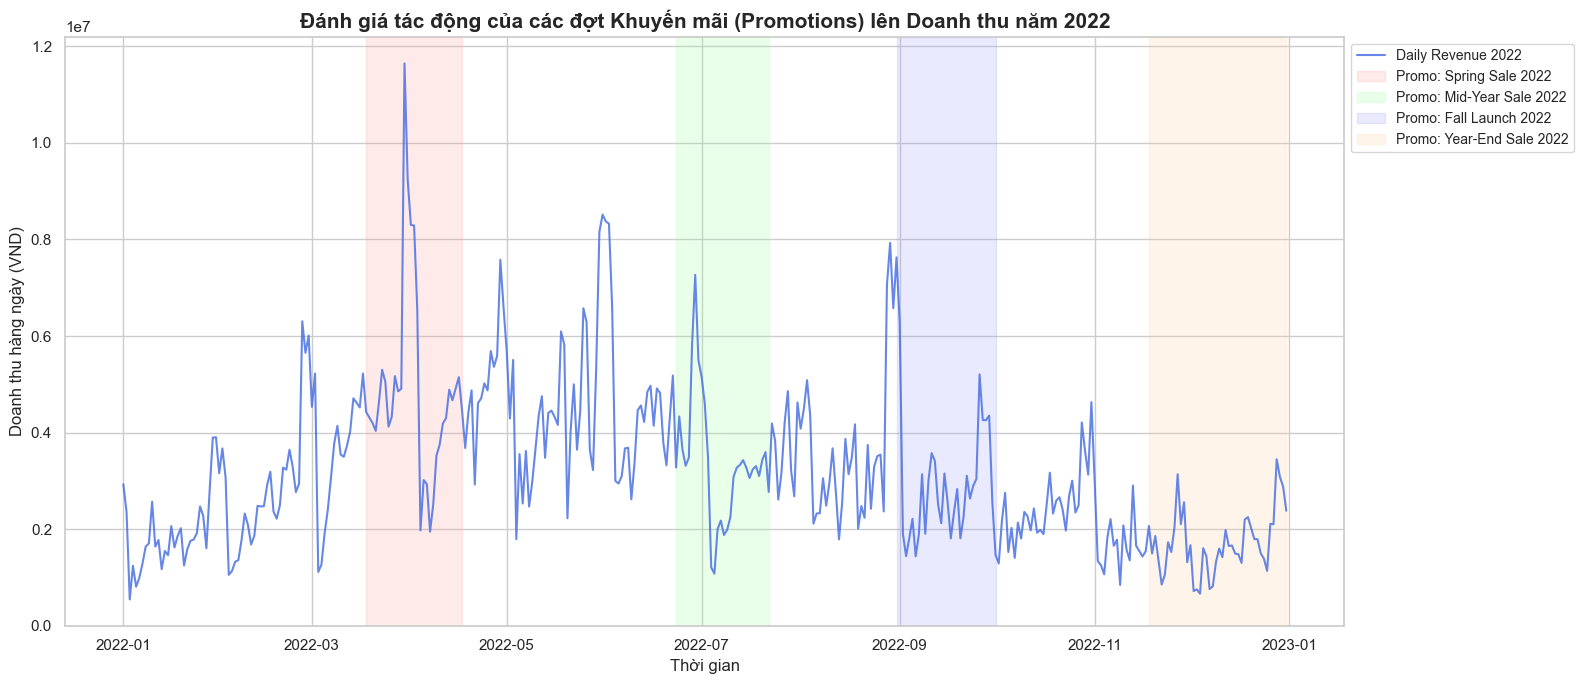

In [15]:
# 1. Đọc và làm sạch promotions.csv
df_promo = pd.read_csv(os.path.join(data_dir, "promotions.csv"))
df_promo.dropna(how='all', inplace=True)
df_promo['start_date'] = pd.to_datetime(df_promo['start_date'])
df_promo['end_date'] = pd.to_datetime(df_promo['end_date'])

# 2. Lọc chuỗi thời gian doanh thu hàng ngày trong năm 2022
sales_2022 = df_sales.loc['2022-01-01':'2022-12-31']

# 3. Lọc danh sách promotions chạy trong năm 2022
promo_2022 = df_promo[(df_promo['start_date'] >= '2022-01-01') & (df_promo['end_date'] <= '2022-12-31')]

# 4. Vẽ đồ thị
plt.figure(figsize=(16, 7))
plt.plot(sales_2022.index, sales_2022['Revenue'], label='Daily Revenue 2022', color='royalblue', alpha=0.8, linewidth=1.5)

# Tô màu nền cho từng chiến dịch khuyến mãi
colors = ['#ff9999', '#99ff99', '#9999ff', '#ffcc99', '#ffff99', '#cc99ff', '#ff99ff']
color_idx = 0

for _, row in promo_2022.iterrows():
    p_name = row['promo_name']
    s_date = row['start_date']
    e_date = row['end_date']
    
    # Tô vùng màu từ start_date tới end_date
    plt.axvspan(s_date, e_date, color=colors[color_idx % len(colors)], alpha=0.2, label=f"Promo: {p_name}")
    color_idx += 1

plt.title("Đánh giá tác động của các đợt Khuyến mãi (Promotions) lên Doanh thu năm 2022", fontsize=15, fontweight='bold')
plt.xlabel("Thời gian")
plt.ylabel("Doanh thu hàng ngày (VND)")

# Xử lý hiển thị Legend gọn gàng (loại bỏ lặp lại)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

plt.tight_layout()
plt.show()

**Nhận xét chiến lược:**
- Biểu đồ doanh số năm 2022 thể hiện rõ rệt sự gia tăng doanh số mang tính **đột biến cực lớn (spikes)** trùng khớp hoàn toàn với các chiến dịch khuyến mãi như *Spring Sale 2022*, *Mid-Year Sale 2022*, *Fall Launch 2022*, và đỉnh điểm là chiến dịch *Spring Sale 2022*.
- Đối với mô hình forecasting, việc gắn nhãn các ngày diễn ra chương trình khuyến mãi (`promo_flag` hoặc `discount_rate`) là bắt buộc để mô hình có thể bóc tách tác động của các cú sốc bên ngoài này ra khỏi nhu cầu mua hàng tự nhiên.